<a href="https://colab.research.google.com/github/greeshmapj/AI-course-notes/blob/main/Sec22_dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [123]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('iris')
df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


In [124]:
feature = df.drop('species',axis=1)
feature.head(4)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2


In [125]:
feature.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<Axes: xlabel='sepal_length', ylabel='petal_length'>

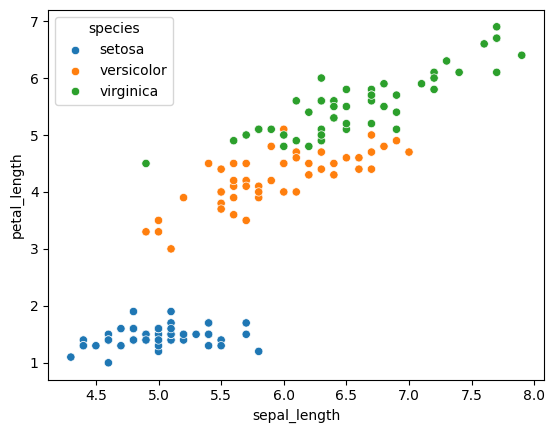

In [126]:
sns.scatterplot(x='sepal_length',y='petal_length',data=df,hue='species')

Finding optimum no.of components for PCA

In [127]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca=PCA()
pca.fit(feature)

PCA()

In [128]:
feature.sample(3)

,sepal_length,sepal_width,petal_length,petal_width
91,6.1,3.0,4.6,1.4
113,5.7,2.5,5.0,2.0
54,6.5,2.8,4.6,1.5


In [129]:
pca.explained_variance_ratio_

array([0.92461872, 0.05306648, 0.01710261, 0.00521218])

In [130]:
0.92461872+ 0.05306648+ 0.01710261+ 0.00521218  #cumulative sum

0.9999999900000001

* 1 component = 92%(8% loss)
* 2 component = 97%(3% loss)
* 3 component = 99%(1% loss)
* 4 component = 100%

In [131]:
import numpy as np
exp_cumsum = np.cumsum(pca.explained_variance_ratio_)
exp_cumsum

array([0.92461872, 0.97768521, 0.99478782, 1.        ])

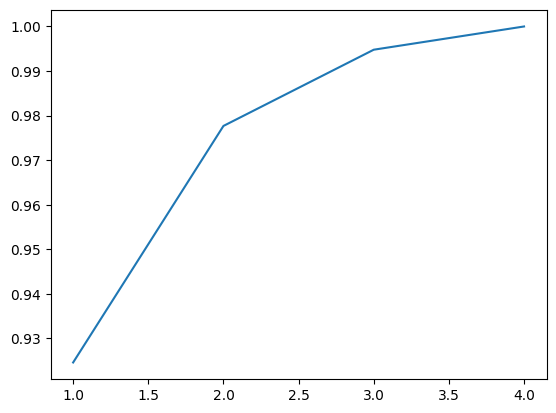

In [132]:
x=range(1,len(exp_cumsum)+1)
y=exp_cumsum
plt.plot(x,y)

optimum n_components = 2

In [133]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pcafeature = pca.fit_transform(feature)

In [134]:
import pandas as pd
pcafeature = pd.DataFrame(pcafeature,columns=['pc1','pc2'])
pcafeature.head(3)

,pc1,pc2
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949


In [135]:
#Adding species column to new df
pcafeature['species']=df['species']
pcafeature.head(3)

,pc1,pc2,species
0,-2.684126,0.319397,setosa
1,-2.714142,-0.177001,setosa
2,-2.888991,-0.144949,setosa


<Axes: xlabel='pc1', ylabel='pc2'>

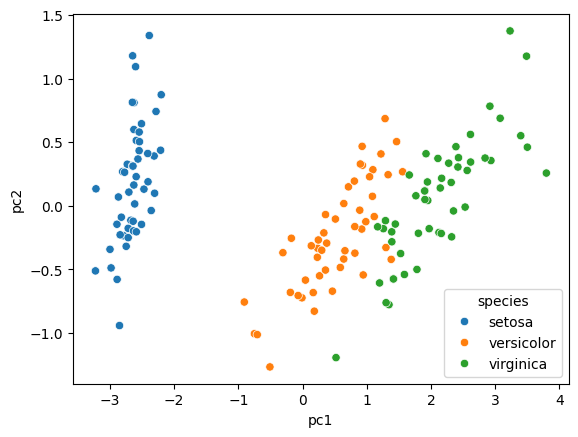

In [136]:
sns.scatterplot(x='pc1',y='pc2',data=pcafeature,hue='species')

**Breast Cancer Problem**

In [137]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
X.sample(3) # features

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
508,16.30,15.70,104.70,819.8,0.09427,0.06712,0.05526,0.04563,0.1711,0.05657,...,17.32,17.76,109.8,928.2,0.1354,0.1361,0.19470,0.13570,0.2300,0.07230
219,19.53,32.47,128.00,1223.0,0.08420,0.11300,0.11450,0.06637,0.1428,0.05313,...,27.90,45.41,180.2,2477.0,0.1408,0.4097,0.39950,0.16250,0.2713,0.07568
169,14.97,16.95,96.22,685.9,0.09855,0.07885,0.02602,0.03781,0.1780,0.05650,...,16.11,23.00,104.6,793.7,0.1216,0.1637,0.06648,0.08485,0.2404,0.06428


In [138]:
# Let’s artificially add categorical features
X["Gender"] = ["Male" if i%2==0 else "Female" for i in range(len(X))]
X["Region"] = ["Urban" if i%3==0 else "Rural" for i in range(len(X))]

X.sample(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Gender,Region
178,13.01,22.22,82.01,526.4,0.06251,0.01938,0.001595,0.001852,0.1395,0.05234,...,88.18,608.8,0.08125,0.03432,0.007977,0.009259,0.2295,0.05843,Male,Rural
124,13.37,16.39,86.10,553.5,0.07115,0.07325,0.080920,0.028000,0.1422,0.05823,...,91.99,632.1,0.10250,0.25310,0.330800,0.089780,0.2048,0.07628,Male,Rural
89,14.64,15.24,95.77,651.9,0.11320,0.13390,0.099660,0.070640,0.2116,0.06346,...,109.40,803.6,0.12770,0.30890,0.260400,0.139700,0.3151,0.08473,Female,Rural


In [139]:
num_cols = X.select_dtypes(include=['float64', 'int64']).columns #scale
cat_cols = X.select_dtypes(include=['object']).columns #encode
num_cols

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [140]:
cat_cols
min=['mean radius']

In [141]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols)
])

In [142]:
X_processed = preprocessor.fit_transform(X)

In [143]:
X_processed.shape
x_data=pd.DataFrame(X_processed,columns=X.columns)

In [144]:
round(x_data.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Gender,Region
count,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,...,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0
mean,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,...,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,1.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
min,-2.0,-2.0,-2.0,-1.0,-3.0,-2.0,-1.0,-1.0,-3.0,-2.0,...,-2.0,-1.0,-3.0,-1.0,-1.0,-2.0,-2.0,-2.0,0.0,0.0
25%,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0
50%,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,1.0,0.0
75%,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
max,4.0,5.0,4.0,5.0,5.0,5.0,4.0,4.0,4.0,5.0,...,4.0,6.0,4.0,5.0,5.0,3.0,6.0,7.0,1.0,1.0


In [145]:
from sklearn.decomposition import PCA

pca = PCA(n_components=.97)  # retain 97% variance
X_pca = pca.fit_transform(X_processed)
print("Final dimension after PCA:", X_pca.shape[1])

Final dimension after PCA: 14


In [146]:
import numpy as np
pca=PCA( )
pca.fit(X_processed)
y=np.cumsum(pca.explained_variance_ratio_)
print(y)

[0.43587373 0.6226776  0.71515524 0.78016504 0.83430511 0.87394205
 0.89611239 0.91178445 0.92553461 0.93715885 0.94682017 0.95569852
 0.96410961 0.97154373 0.97856951 0.98369351 0.98675891 0.98935893
 0.99129533 0.99302154 0.99464076 0.9956626  0.99664138 0.99753415
 0.99832814 0.99891824 0.99942532 0.99969345 0.99991911 0.99997115
 0.99999569 1.        ]


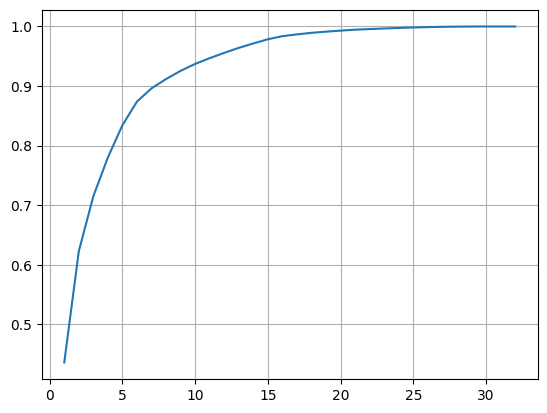

In [147]:
import matplotlib.pyplot as plt
plt.plot(range(1,len(y)+1),y)
plt.grid()

In [148]:
X_pca.shape[1]

14

In [149]:
X_pca=pd.DataFrame(X_pca,columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
X_pca.sample(2)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
391,-3.598434,2.602414,1.850496,-0.076453,2.460542,-1.858366,1.535031,0.474402,-0.693149,0.92681,1.177705,-0.781708,0.781311,-0.508485
28,4.008560,0.544912,-2.758801,1.893282,0.512455,0.196131,0.179777,0.378747,0.438216,-0.62256,-0.351972,0.222588,0.330538,0.069139


<Axes: xlabel='PC1', ylabel='PC2'>

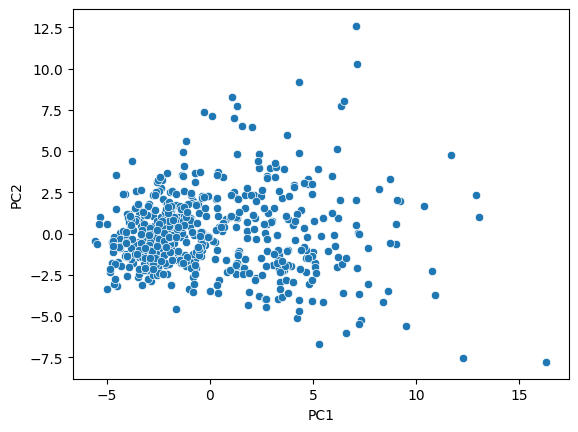

In [150]:
import seaborn as sns
sns.scatterplot(x="PC1",y="PC2",data=X_pca)

In [151]:
X_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
0,9.197720,1.947874,-1.123252,-3.640852,1.181649,1.429205,2.167902,-0.446435,-0.109257,-0.952317,0.200113,-0.738255,0.658282,0.233770
1,2.383892,-3.770517,-0.529753,-1.110792,-0.602412,0.012631,-0.004616,0.288836,-0.803813,1.192662,0.835560,-0.187086,-0.810232,0.317420
2,5.735159,-1.067221,-0.548559,-0.916907,0.170728,0.541136,-0.654393,0.111374,0.065125,0.396874,-0.591417,0.324782,-0.077481,0.444006
3,7.122742,10.262998,-3.238540,-0.142257,2.965234,3.060449,1.406256,1.034845,-1.442989,-1.101705,-1.135341,0.078360,-1.501355,0.337745
4,3.936610,-1.939670,1.393322,-2.945880,-0.546677,-1.228892,-0.922748,0.649867,-0.208915,0.296192,0.646661,0.325490,0.610746,-0.007672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,6.444085,-3.576807,2.459917,-1.185495,0.061191,-2.357961,-0.581996,-0.087647,1.025137,0.180939,-0.123339,0.042079,0.172941,0.490389
565,3.789408,-3.586517,2.087556,2.515134,0.522069,-0.257389,-0.726570,-1.080994,-0.153381,-0.000349,0.301055,0.058762,-0.521078,-0.305790
566,1.257519,-1.893983,0.566006,2.080463,-1.821902,-0.535073,-0.176559,0.350013,0.442714,0.450417,-0.835065,0.470978,0.317898,0.137928
567,10.374379,1.660193,-1.881700,2.360873,0.035261,0.572368,0.205024,-0.305445,-0.594732,-0.088073,-0.234897,-0.579333,0.885240,-0.932159


**KMeans**

In [152]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=2)
X_pca["target"]=kmeans.fit_predict(X_pca)
X_pca

silhouette_score(X_pca,kmeans.labels_) #-1 to 1

np.float64(0.35176191058912304)

In [ ]:
import seaborn as sns
sns.scatterplot(x="PC1",y="PC10",data=X_pca,hue="target")

<Axes: xlabel='PC1', ylabel='PC10'>

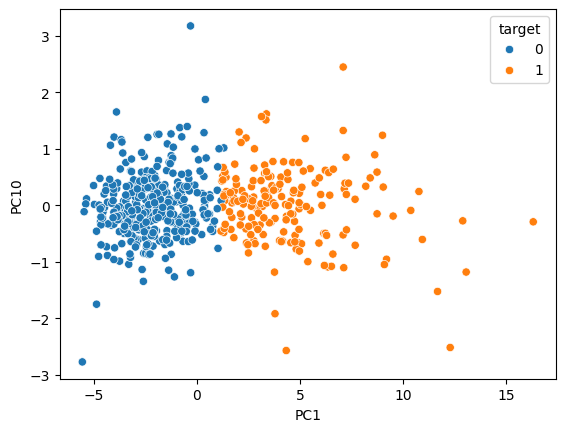

In [153]:
import seaborn as sns
sns.scatterplot(x="PC1",y="PC10",data=X_pca,hue="target")